# Experiment: LDA SVD — NumPy vs PyTorch CPU vs MPS (Array API) Performance

Objective:
- Compare `LinearDiscriminantAnalysis(solver='svd')` performance when given **NumPy arrays**, **PyTorch CPU tensors**, and **PyTorch MPS tensors** (Apple Silicon GPU) via Array API dispatch.
- Measure holdout accuracy, training time, and peak memory for both batch `fit` and streaming `partial_fit`.
- Batch `fit()` with Array API dispatch uses `xp.linalg.svd` (torch on-device SVD), so MPS tensors run SVD on the GPU.
- Streaming `partial_fit()` converts to NumPy at the entry point for float64 accumulation.

**Important**: `SCIPY_ARRAY_API=1` must be set before importing scipy/sklearn.

In [1]:
import os
os.environ["SCIPY_ARRAY_API"] = "1"

from __future__ import annotations

import gc
import tracemalloc
from time import perf_counter

import numpy as np
import torch

from sklearn import config_context
from sklearn.datasets import fetch_openml
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

print(f"torch {torch.__version__}")
print(f"SCIPY_ARRAY_API={os.environ.get('SCIPY_ARRAY_API')}")

torch 2.8.0
SCIPY_ARRAY_API=1


## Dataset and benchmark configuration

In [2]:
SEED = 42
N_SPLITS = 5
STREAM_BATCH_SIZES = (512, 1024, 2048)
BATCH_FIT_LABEL = 'full-fit'

OPENML_DATASET = 'mnist_784'
OPENML_VERSION = 1
MAX_SAMPLES = 25_000

SOLVER = 'svd'
MODES = ('batch', 'streaming')

HAS_MPS = torch.backends.mps.is_available()


def load_openml_dataset(name: str, version: int):
    try:
        return fetch_openml(name=name, version=version, as_frame=False, parser="auto")
    except TypeError:
        return fetch_openml(name=name, version=version, as_frame=False)


mnist = load_openml_dataset(OPENML_DATASET, OPENML_VERSION)
X_np = np.asarray(mnist.data, dtype=np.float32)
y_np = np.asarray(mnist.target).astype(np.int64, copy=False)
source_samples = X_np.shape[0]

if MAX_SAMPLES is not None and MAX_SAMPLES < source_samples:
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=MAX_SAMPLES, random_state=SEED)
    subset_idx, _ = next(splitter.split(X_np, y_np))
    X_np = X_np[subset_idx]
    y_np = y_np[subset_idx]

CLASSES = np.unique(y_np)

# Create PyTorch CPU tensors (.copy() to decouple memory from numpy originals)
X_torch_cpu = torch.from_numpy(X_np.copy())
y_torch_cpu = torch.from_numpy(y_np.copy())

# Create MPS tensors if available
if HAS_MPS:
    X_torch_mps = X_torch_cpu.to("mps")
    y_torch_mps = y_torch_cpu.to("mps")

print(f"Dataset: OpenML/{OPENML_DATASET} (v{OPENML_VERSION})")
print(f"Samples={X_np.shape[0]} (from {source_samples}), Features={X_np.shape[1]}, Classes={len(CLASSES)}")
print(f"X_np dtype={X_np.dtype}, X_torch_cpu dtype={X_torch_cpu.dtype}")
print(f"MPS available={HAS_MPS}")
print(f"Solver={SOLVER}, Modes={MODES}, Folds={N_SPLITS}")
print(f"Streaming batch-size sweep={STREAM_BATCH_SIZES}")

Dataset: OpenML/mnist_784 (v1)
Samples=25000 (from 70000), Features=784, Classes=10
X_np dtype=float32, X_torch_cpu dtype=torch.float32
MPS available=True
Solver=svd, Modes=('batch', 'streaming'), Folds=5
Streaming batch-size sweep=(512, 1024, 2048)


## Helpers

- Each training call is measured in a **single run** with `tracemalloc` to capture both time and peak memory.
- Batch `fit()` with torch tensors uses `xp.linalg.svd` — stays on-device (CPU or MPS GPU).
- Streaming `partial_fit()` converts to NumPy internally for float64 accumulation.
- For MPS batch `fit()`, `torch.mps.synchronize()` is called before stopping the timer to ensure GPU work is complete.

Note: `tracemalloc` tracks CPython allocations. PyTorch's internal allocator (CPU and MPS) is not tracked,
so memory figures reflect sklearn-side overhead rather than total process memory.

In [3]:
def build_estimator() -> LinearDiscriminantAnalysis:
    return LinearDiscriminantAnalysis(solver=SOLVER)


def fit_streaming(
    estimator: LinearDiscriminantAnalysis,
    X_train,
    y_train,
    classes: np.ndarray,
    batch_size: int,
) -> LinearDiscriminantAnalysis:
    n_samples = X_train.shape[0]
    for start in range(0, n_samples, batch_size):
        stop = min(start + batch_size, n_samples)
        X_chunk = X_train[start:stop]
        y_chunk = y_train[start:stop]
        if start == 0:
            estimator.partial_fit(X_chunk, y_chunk, classes=classes)
        else:
            estimator.partial_fit(X_chunk, y_chunk)
    return estimator


def benchmark_training(train_builder, *, sync_mps=False):
    """Single run measuring wall time and peak tracemalloc memory."""
    gc.collect()
    tracemalloc.start()
    t0 = perf_counter()
    model = train_builder()
    if sync_mps:
        torch.mps.synchronize()
    train_time_s = perf_counter() - t0
    _, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peak_mem_mb = peak_bytes / (1024 ** 2)
    return model, train_time_s, peak_mem_mb


def run_benchmark(X_data, y_data, X_test_data, backend_label, *,
                  predict_X_override=None, sync_mps=False):
    """Run 5-fold CV benchmark for a given backend.

    Parameters
    ----------
    X_data, y_data : training data (numpy, torch CPU, or torch MPS)
    X_test_data : data used for predict() — must match model state namespace
    backend_label : str for record tagging
    predict_X_override : if set, use this for predict after streaming
        (needed when partial_fit converts to numpy internally)
    sync_mps : whether to call torch.mps.synchronize() after training
    """
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    records = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_np, y_np), start=1):
        X_train = X_data[train_idx]
        y_train = y_data[train_idx]
        X_test = X_test_data[test_idx]
        y_test = y_np[test_idx]

        # For streaming predict after partial_fit (converts to numpy)
        X_test_stream = predict_X_override[test_idx] if predict_X_override is not None else X_test

        rng = np.random.default_rng(SEED + fold_idx)
        order = rng.permutation(len(train_idx))
        X_train_stream = X_train[order]
        y_train_stream = y_train[order]

        # Batch
        batch_builder = lambda: build_estimator().fit(X_train, y_train)
        batch_model, t, mem = benchmark_training(batch_builder, sync_mps=sync_mps)
        records.append({
            'fold': fold_idx, 'backend': backend_label, 'mode': 'batch',
            'batch_size': BATCH_FIT_LABEL,
            'accuracy': accuracy_score(y_test, batch_model.predict(X_test)),
            'train_time_s': t, 'peak_mem_mb': mem,
        })
        del batch_model

        # Streaming
        for bs in STREAM_BATCH_SIZES:
            stream_builder = lambda bs=bs: fit_streaming(
                build_estimator(), X_train_stream, y_train_stream,
                classes=CLASSES, batch_size=bs,
            )
            stream_model, t, mem = benchmark_training(stream_builder)
            records.append({
                'fold': fold_idx, 'backend': backend_label, 'mode': 'streaming',
                'batch_size': int(bs),
                'accuracy': accuracy_score(y_test, stream_model.predict(X_test_stream)),
                'train_time_s': t, 'peak_mem_mb': mem,
            })
            del stream_model

        gc.collect()
        print(f"  [{backend_label}] Fold {fold_idx}/{N_SPLITS} done.")

    print(f"{backend_label}: collected {len(records)} rows.")
    return records

## NumPy benchmark (baseline)

In [4]:
np_records = run_benchmark(X_np, y_np, X_np, 'numpy')

  [numpy] Fold 1/5 done.
  [numpy] Fold 2/5 done.
  [numpy] Fold 3/5 done.
  [numpy] Fold 4/5 done.
  [numpy] Fold 5/5 done.
numpy: collected 20 rows.


## PyTorch CPU (Array API) benchmark

In [5]:
with config_context(array_api_dispatch=True):
    torch_cpu_records = run_benchmark(
        X_torch_cpu, y_torch_cpu, X_torch_cpu, 'torch_cpu',
        predict_X_override=X_np,  # streaming partial_fit stores state as numpy
    )

  [torch_cpu] Fold 1/5 done.
  [torch_cpu] Fold 2/5 done.
  [torch_cpu] Fold 3/5 done.
  [torch_cpu] Fold 4/5 done.
  [torch_cpu] Fold 5/5 done.
torch_cpu: collected 20 rows.


## PyTorch MPS (Apple Silicon GPU) benchmark

Batch `fit()` runs `torch.linalg.svd` on the MPS GPU. Streaming `partial_fit()` converts to NumPy
(CPU), so MPS only accelerates the batch path.

In [6]:
if HAS_MPS:
    with config_context(array_api_dispatch=True):
        mps_records = run_benchmark(
            X_torch_mps, y_torch_mps, X_torch_mps, 'torch_mps',
            predict_X_override=X_np,  # streaming partial_fit stores state as numpy
            sync_mps=True,
        )
else:
    mps_records = []
    print("MPS not available — skipping.")

/Users/willcobb/Code.local/scikit-learn-inclda/sklearn/discriminant_analysis.py:631: UserWarning: The operator 'aten::linalg_svd' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:15.)
  _, S, Vt = svd(X, full_matrices=False)


  [torch_mps] Fold 1/5 done.
  [torch_mps] Fold 2/5 done.
  [torch_mps] Fold 3/5 done.
  [torch_mps] Fold 4/5 done.
  [torch_mps] Fold 5/5 done.
torch_mps: collected 20 rows.


## Combined summary table

In [7]:
all_records = np_records + torch_cpu_records + mps_records
METRICS = ('accuracy', 'train_time_s', 'peak_mem_mb')
BACKENDS = ('numpy', 'torch_cpu', 'torch_mps')


def summarize_records(records, backends=BACKENDS):
    summary = []
    for backend in backends:
        for mode in MODES:
            batch_sizes = (BATCH_FIT_LABEL,) if mode == 'batch' else STREAM_BATCH_SIZES
            for batch_size in batch_sizes:
                subset = [
                    r for r in records
                    if r['backend'] == backend
                    and r['mode'] == mode
                    and r['batch_size'] == batch_size
                ]
                if not subset:
                    continue
                row = {
                    'backend': backend, 'mode': mode,
                    'batch_size': batch_size, 'n': len(subset),
                }
                for metric in METRICS:
                    values = np.array([r[metric] for r in subset], dtype=float)
                    finite = values[np.isfinite(values)]
                    if finite.size == 0:
                        row[f'{metric}_mean'] = np.nan
                        row[f'{metric}_std'] = np.nan
                    elif finite.size == 1:
                        row[f'{metric}_mean'] = finite[0]
                        row[f'{metric}_std'] = 0.0
                    else:
                        row[f'{metric}_mean'] = finite.mean()
                        row[f'{metric}_std'] = finite.std(ddof=1)
                summary.append(row)
    return summary


summary_rows = summarize_records(all_records)


def fmt(mean, std, precision=4):
    if not np.isfinite(mean):
        return 'n/a'
    return f"{mean:.{precision}f} +/- {std:.{precision}f}"


def print_summary_table(summary_rows):
    header = (
        f"{'backend':<11} {'mode':<10} {'batch_size':<11}"
        f" {'accuracy':>18} {'time_s':>18} {'peak_mem_mb':>18}"
    )
    print(header)
    print('-' * len(header))
    for row in summary_rows:
        acc = fmt(row['accuracy_mean'], row['accuracy_std'])
        t = fmt(row['train_time_s_mean'], row['train_time_s_std'])
        m = fmt(row['peak_mem_mb_mean'], row['peak_mem_mb_std'], precision=2)
        print(
            f"{row['backend']:<11} {row['mode']:<10} {str(row['batch_size']):<11}"
            f" {acc:>18} {t:>18} {m:>18}"
        )


print("LDA SVD: NumPy vs PyTorch CPU vs MPS")
print("=" * 65)
print_summary_table(summary_rows)

LDA SVD: NumPy vs PyTorch CPU vs MPS
backend     mode       batch_size            accuracy             time_s        peak_mem_mb
-------------------------------------------------------------------------------------------
numpy       batch      full-fit     0.8626 +/- 0.0057  0.4599 +/- 0.0051    257.02 +/- 0.00
numpy       streaming  512          0.8626 +/- 0.0057  2.2888 +/- 0.0404     47.97 +/- 0.08
numpy       streaming  1024         0.8626 +/- 0.0057  1.6094 +/- 0.0269     64.87 +/- 0.08
numpy       streaming  2048         0.8626 +/- 0.0057  1.1520 +/- 0.0181     89.31 +/- 0.06
torch_cpu   batch      full-fit     0.8626 +/- 0.0057  0.3927 +/- 0.0202      0.44 +/- 0.95
torch_cpu   streaming  512          0.8626 +/- 0.0057  2.1676 +/- 0.0130     48.00 +/- 0.08
torch_cpu   streaming  1024         0.8626 +/- 0.0057  1.6021 +/- 0.0147     64.89 +/- 0.08
torch_cpu   streaming  2048         0.8626 +/- 0.0057  1.1312 +/- 0.0099     89.32 +/- 0.06
torch_mps   batch      full-fit     0.8626 

## Side-by-side comparison

For each mode/batch_size, compare all backends against the NumPy baseline.

In [8]:
lookup = {(r['backend'], r['mode'], r['batch_size']): r for r in summary_rows}

all_configs = [
    ('batch', BATCH_FIT_LABEL),
] + [('streaming', int(bs)) for bs in STREAM_BATCH_SIZES]

# Compare each non-numpy backend against numpy
compare_backends = [b for b in BACKENDS if b != 'numpy' and any(r['backend'] == b for r in all_records)]

for compare_backend in compare_backends:
    label = compare_backend.replace('_', ' ').upper()
    print(f"\n{'='*90}")
    print(f"  {label} vs NUMPY")
    print(f"{'='*90}")
    header = (
        f"{'mode':<10} {'batch_size':<11}"
        f" {'acc_match':>10}"
        f" {'np_time':>10} {'pt_time':>10} {'speedup':>9}"
        f" {'np_mem':>10} {'pt_mem':>10} {'mem_ratio':>11}"
    )
    print(header)
    print('-' * len(header))

    for mode, bs in all_configs:
        np_row = lookup.get(('numpy', mode, bs))
        pt_row = lookup.get((compare_backend, mode, bs))
        if np_row is None or pt_row is None:
            continue

        acc_match = abs(np_row['accuracy_mean'] - pt_row['accuracy_mean']) < 1e-10
        np_t = np_row['train_time_s_mean']
        pt_t = pt_row['train_time_s_mean']
        np_m = np_row['peak_mem_mb_mean']
        pt_m = pt_row['peak_mem_mb_mean']

        speedup = np_t / pt_t if pt_t > 0 else float('nan')
        mem_ratio = pt_m / np_m if np_m > 0 else float('nan')

        print(
            f"{mode:<10} {str(bs):<11}"
            f" {str(acc_match):>10}"
            f" {np_t:>9.3f}s {pt_t:>9.3f}s {speedup:>8.2f}x"
            f" {np_m:>8.1f}MB {pt_m:>8.1f}MB {mem_ratio:>10.2f}x"
        )

print()
print("speedup   = NumPy/Backend (>1 means backend is faster)")
print("mem_ratio = Backend/NumPy (>1 means backend uses more memory)")


  TORCH CPU vs NUMPY
mode       batch_size   acc_match    np_time    pt_time   speedup     np_mem     pt_mem   mem_ratio
---------------------------------------------------------------------------------------------------
batch      full-fit         False     0.460s     0.393s     1.17x    257.0MB      0.4MB       0.00x
streaming  512               True     2.289s     2.168s     1.06x     48.0MB     48.0MB       1.00x
streaming  1024              True     1.609s     1.602s     1.00x     64.9MB     64.9MB       1.00x
streaming  2048              True     1.152s     1.131s     1.02x     89.3MB     89.3MB       1.00x

  TORCH MPS vs NUMPY
mode       batch_size   acc_match    np_time    pt_time   speedup     np_mem     pt_mem   mem_ratio
---------------------------------------------------------------------------------------------------
batch      full-fit         False     0.460s     0.523s     0.88x    257.0MB      0.0MB       0.00x
streaming  512               True     2.289s     2.249s 

## Visual comparison

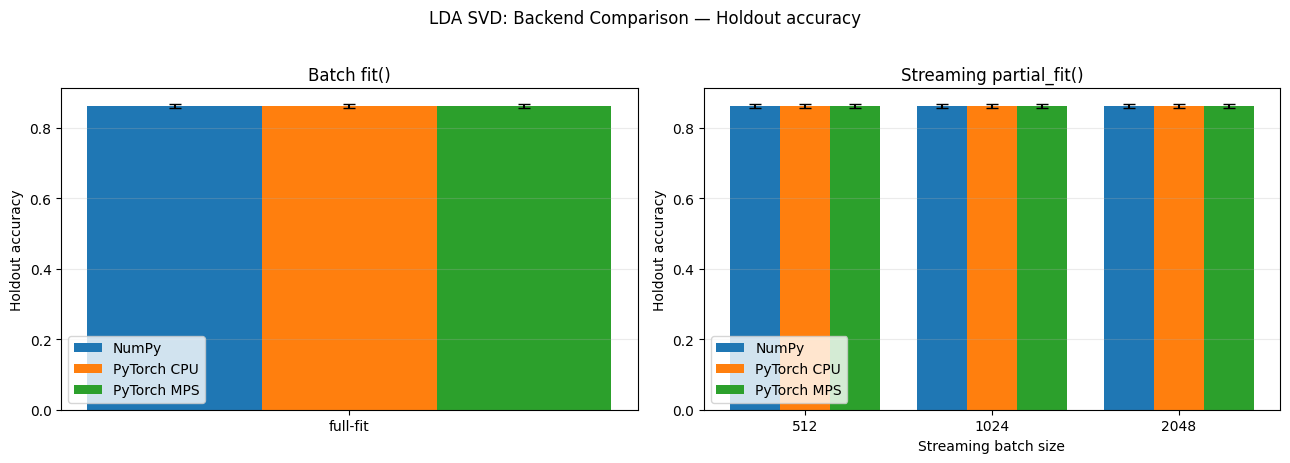

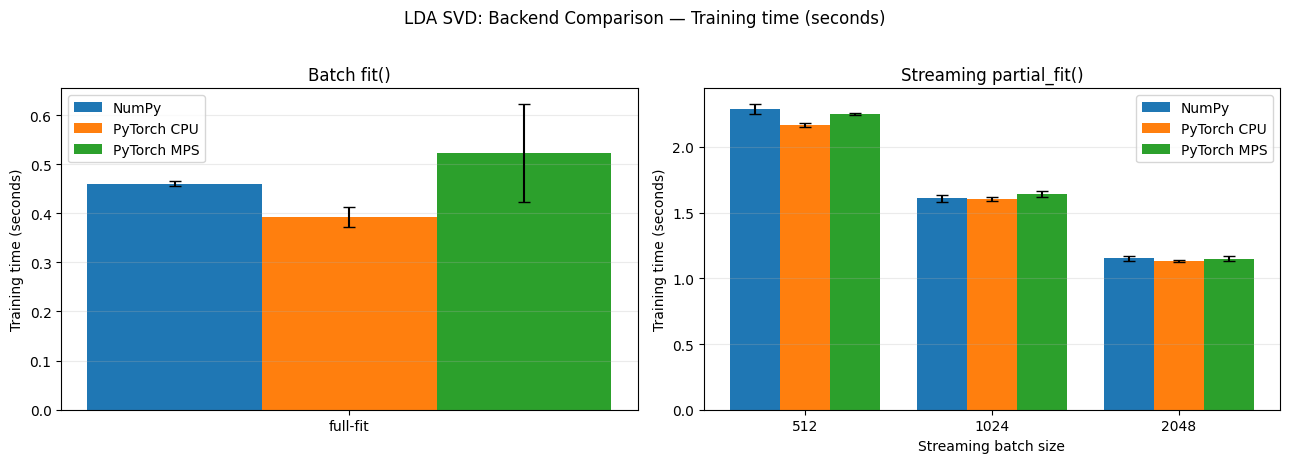

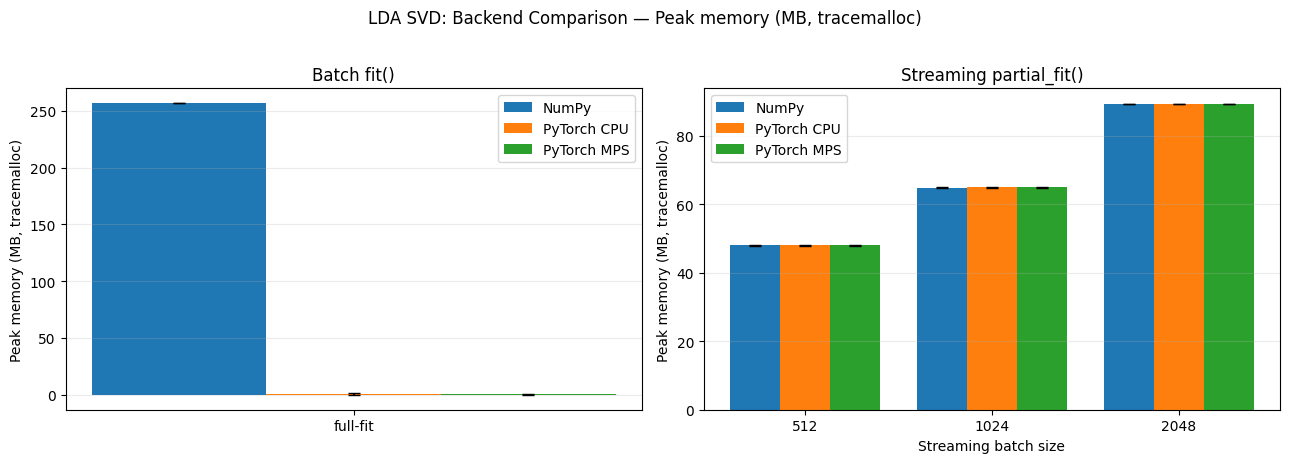

In [9]:
import matplotlib.pyplot as plt

STREAM_BATCH_SIZES_SORTED = tuple(sorted(int(x) for x in STREAM_BATCH_SIZES))

# Only plot backends that have data
active_backends = [b for b in BACKENDS if any(r['backend'] == b for r in all_records)]
backend_colors = {'numpy': 'tab:blue', 'torch_cpu': 'tab:orange', 'torch_mps': 'tab:green'}
backend_labels = {'numpy': 'NumPy', 'torch_cpu': 'PyTorch CPU', 'torch_mps': 'PyTorch MPS'}


def plot_comparison(metric, ylabel):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    n_backends = len(active_backends)
    width = 0.8 / n_backends

    for ax, mode_label, title in [
        (axes[0], 'batch', 'Batch fit()'),
        (axes[1], 'streaming', 'Streaming partial_fit()'),
    ]:
        if mode_label == 'batch':
            bx = np.array([0.0])
            for i, backend in enumerate(active_backends):
                row = lookup.get((backend, 'batch', BATCH_FIT_LABEL))
                if row:
                    offset = (i - (n_backends - 1) / 2) * width
                    ax.bar(
                        bx + offset,
                        [row[f'{metric}_mean']], width,
                        yerr=[row[f'{metric}_std']],
                        label=backend_labels[backend],
                        color=backend_colors[backend],
                        capsize=4,
                    )
            ax.set_xticks(bx)
            ax.set_xticklabels(['full-fit'])
        else:
            x = np.arange(len(STREAM_BATCH_SIZES_SORTED), dtype=float)
            for i, backend in enumerate(active_backends):
                means, stds = [], []
                for bs in STREAM_BATCH_SIZES_SORTED:
                    row = lookup.get((backend, 'streaming', bs))
                    if row:
                        means.append(row[f'{metric}_mean'])
                        stds.append(row[f'{metric}_std'])
                    else:
                        means.append(0)
                        stds.append(0)
                offset = (i - (n_backends - 1) / 2) * width
                ax.bar(
                    x + offset, means, width, yerr=stds,
                    label=backend_labels[backend],
                    color=backend_colors[backend],
                    capsize=4,
                )
            ax.set_xticks(x)
            ax.set_xticklabels([str(bs) for bs in STREAM_BATCH_SIZES_SORTED])
            ax.set_xlabel('Streaming batch size')

        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(alpha=0.25, axis='y')

    fig.suptitle(f'LDA SVD: Backend Comparison — {ylabel}', y=1.02)
    plt.tight_layout()
    plt.show()


plot_comparison('accuracy', 'Holdout accuracy')
plot_comparison('train_time_s', 'Training time (seconds)')
plot_comparison('peak_mem_mb', 'Peak memory (MB, tracemalloc)')

## Takeaways

- PyTorch tensors (CPU and MPS) are accepted by both `fit()` and `partial_fit()` when `array_api_dispatch=True`.
- **Accuracy**: Identical across all three backends for both batch and streaming modes.
- **Batch `fit()`**: Uses `xp.linalg.svd` — stays on-device. MPS runs SVD on the Apple Silicon GPU.
- **Streaming `partial_fit()`**: Converts to NumPy at the entry point for float64 accumulation. MPS and CPU streaming performance should be similar since both go through NumPy.
- **Memory**: `tracemalloc` captures Python-side (CPython) allocations only. PyTorch's internal allocator (CPU and MPS) is not tracked, so memory figures reflect sklearn overhead rather than total process memory.